## Wearable Tech: Week 3 Assignment

### Step 1

In [1]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
import matplotlib.dates as mdates

from datetime import datetime
import plotly.graph_objects as go

df = pd.read_csv("/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 4 - Wearable Technologies and Sports Analytics/Week 3 Content/Week 3 Assignment/WBBtotal.csv", index_col =["Timestamp"], parse_dates=["Timestamp"])

/tmp/ipykernel_1004/165550526.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 4 - Wearable Technologies and Sports Analytics/Week 3 Content/Week 3 Assignment/WBBtotal.csv", index_col =["Timestamp"], parse_dates=["Timestamp"])


### Step 2

In [3]:
# Make a new dataset (or dataframe) using only measures of interest (seconds, heart rate, player load and Athlete ID).
columns_to_keep = ['Seconds','Heart Rate', 'Player Load', 'AthleteID']
df_wbb = df[columns_to_keep]
df_wbb

,Seconds,Heart Rate,Player Load,AthleteID
Timestamp,,,,
2019-01-08 17:39:42,0.0,83,0.0,Athlete 1
2019-01-08 17:39:42,0.1,83,0.0,Athlete 1
2019-01-08 17:39:42,0.2,83,0.0,Athlete 1
2019-01-08 17:39:42,0.3,83,0.0,Athlete 1
2019-01-08 17:39:42,0.4,83,0.0,Athlete 1
...,...,...,...,...
2019-03-08 16:47:03,11484.4,101,1001.5,Athlete 5
2019-03-08 16:47:03,11484.5,101,1001.5,Athlete 5
2019-03-08 16:47:03,11484.6,101,1001.5,Athlete 5


### Step 3

In [4]:
# Create a slice of the dataframe to use for this assessment based on the date of the game: March 9, 2019.
Game_3_9_df = df_wbb.loc['2019-03-09']
Game_3_9_df

,Seconds,Heart Rate,Player Load,AthleteID
Timestamp,,,,
2019-03-09 15:57:49,0.0,0,0.0,Athlete 10
2019-03-09 15:57:49,0.1,0,0.0,Athlete 10
2019-03-09 15:57:49,0.2,0,0.0,Athlete 10
2019-03-09 15:57:49,0.3,0,0.0,Athlete 10
2019-03-09 15:57:49,0.4,0,0.0,Athlete 10
...,...,...,...,...
2019-03-09 19:08:14,11348.4,108,470.6,Athlete 8
2019-03-09 19:08:14,11348.5,106,470.6,Athlete 8
2019-03-09 19:08:14,11348.6,106,470.6,Athlete 8


### Step 4

In [5]:
# Determine the total number of HR data points that were recorded with a value of zero.
(Game_3_9_df == 0).sum(axis=0)

,0
Seconds,13
Heart Rate,69452
Player Load,391
AthleteID,0


In [6]:
# Replace 0 values with nan
%%capture
Game_3_9_df.loc[Game_3_9_df['Heart Rate'] ==0, 'Heart Rate'] = np.nan

In [7]:
# See how many values were replaced
DataCount = Game_3_9_df.groupby('AthleteID')[['Heart Rate','Player Load']].count()

print("Count of heart rate and playerload by player ID")
print(DataCount.sort_values(by='Heart Rate', ascending = False))

Count of heart rate and playerload by player ID
            Heart Rate  Player Load
AthleteID                          
Athlete 7       111604       113355
Athlete 4       110829       113749
Athlete 1       110378       113379
Athlete 8       109899       113489
Athlete 2       109071       113829
Athlete 12      109057       113689
Athlete 6       108862       113579
Athlete 5       108154       113629
Athlete 9       108116       113819
Athlete 3       106787       113519
Athlete 13      105498       113346
Athlete 11      105176       113469
Athlete 10      104229       114261


### Step 5

In [8]:
# Determine the % of the missing HR data for each individual athlete.
DataCount['Missing HR values']= (DataCount['Player Load']-DataCount['Heart Rate'])
DataCount['% HR missing'] = DataCount['Missing HR values']/DataCount['Player Load']*100

print(DataCount.sort_values(by='% HR missing', ascending = False))

            Heart Rate  Player Load  Missing HR values  % HR missing
AthleteID                                                           
Athlete 10      104229       114261              10032      8.779899
Athlete 11      105176       113469               8293      7.308604
Athlete 13      105498       113346               7848      6.923932
Athlete 3       106787       113519               6732      5.930285
Athlete 9       108116       113819               5703      5.010587
Athlete 5       108154       113629               5475      4.818312
Athlete 2       109071       113829               4758      4.179954
Athlete 6       108862       113579               4717      4.153056
Athlete 12      109057       113689               4632      4.074273
Athlete 8       109899       113489               3590      3.163302
Athlete 1       110378       113379               3001      2.646875
Athlete 4       110829       113749               2920      2.567056
Athlete 7       111604       11335

### Step 6


In [9]:
Rank_Max_PL = Game_3_9_df.groupby(['AthleteID'])[['Player Load', "Heart Rate"]].max()
print("Maximum playerload (and HR) by player ID")
print(Rank_Max_PL.sort_values(by='Player Load', ascending = False))

Maximum playerload (and HR) by player ID
            Player Load  Heart Rate
AthleteID                          
Athlete 10       1038.8       234.0
Athlete 1         919.4       212.0
Athlete 7         904.5       206.0
Athlete 9         890.8       209.0
Athlete 5         790.5       225.0
Athlete 2         549.3       213.0
Athlete 8         470.6       189.0
Athlete 4         422.6       181.0
Athlete 12        355.9       195.0
Athlete 13        344.8       210.0
Athlete 11        342.1       216.0
Athlete 3         337.3       210.0
Athlete 6         265.9       185.0


,0
AthleteID,
Athlete 10,"Axes(0.125,0.11;0.775x0.77)"
Athlete 6,"Axes(0.125,0.11;0.775x0.77)"


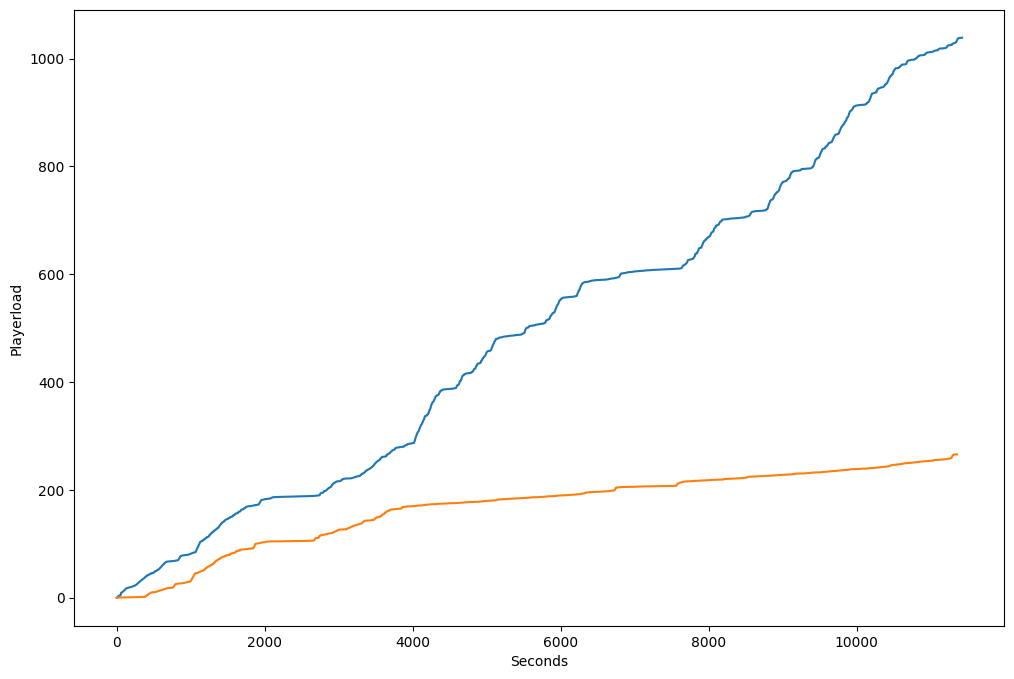

In [10]:
# Plot the heart rates across the session (ie. seconds vs heart rate) for the players with the highest and the lowest player loads for the game session.
# Highest player load = Athlete 10
Ath10_Game_3_9_df = Game_3_9_df.loc[Game_3_9_df['AthleteID'] == 'Athlete 10']
#Lowest player load =  Athlete 6
Ath6_Game_3_9_df = Game_3_9_df.loc[Game_3_9_df['AthleteID'] == 'Athlete 6']
(Game_3_9_df.query("AthleteID == 'Athlete 10' or AthleteID == 'Athlete 6'")
    .groupby("AthleteID")
    .plot(x="Seconds",y="Player Load", ax=plt.gca(), ylabel="Playerload", figsize=(12,8), legend=False))

,0
AthleteID,
Athlete 10,"Axes(0.125,0.11;0.775x0.77)"
Athlete 6,"Axes(0.125,0.11;0.775x0.77)"


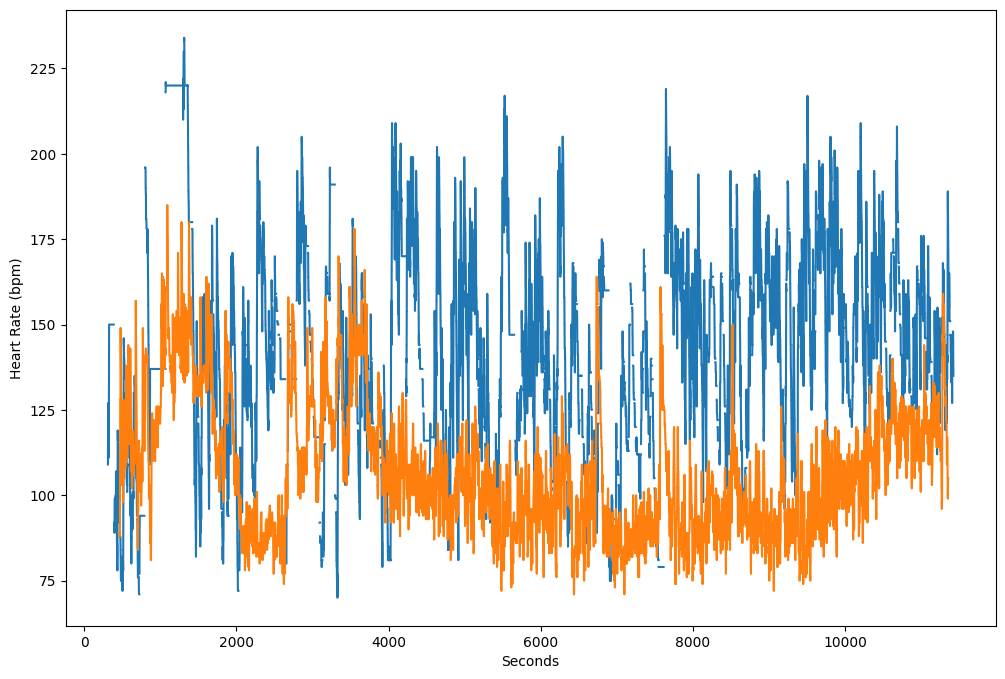

In [11]:
(Game_3_9_df.query("AthleteID == 'Athlete 10' or AthleteID == 'Athlete 6'")
    .groupby("AthleteID")
    .plot(x="Seconds",y="Heart Rate", ax=plt.gca(), ylabel="Heart Rate (bpm)", figsize=(12,8), legend=False))

### Step 7

<Axes: xlabel='Seconds'>

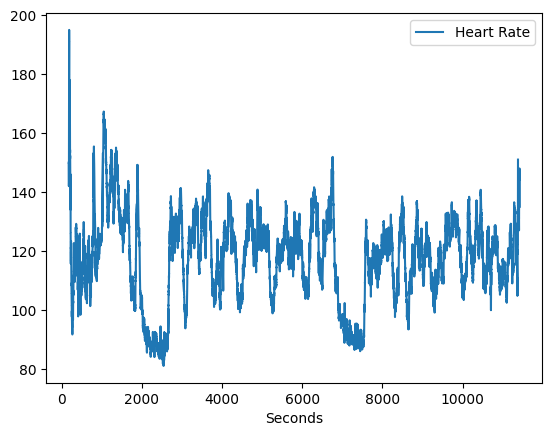

In [12]:
# Plot the heart rates across the session (ie. seconds vs heart rate) for the mean of all players for the game session and
# use the values to estimate when the half-time period occurred (approximately how many seconds (or minutes) into the session.
Team_Mean_HR2 = Game_3_9_df.groupby(['Seconds'])[['Heart Rate']].mean()
Team_Mean_HR2.plot(y='Heart Rate')

As we can see the dip in between what looks like the first and second half of the game, we can estimate that half-time occured around 7500 seconds.

### Step 8


In [13]:
# Using the same estimations as the workbook (i.e. maximal heart rate of 200 beats per minute and resting heart rate of 60),
# calculate the TRIMP value for each player on the team.
Rank_Mean_HR = Game_3_9_df.groupby(['AthleteID'])[['Heart Rate']].mean()
t= 12000/60
HRmax=200
HRrest=60
FHRR = (Rank_Mean_HR['Heart Rate']-HRrest)/ (HRmax-HRrest)
kval = (np.exp(1.67 * FHRR))
TRIMP = t * FHRR * kval
InternalLoads=pd.concat([TRIMP, Rank_Mean_HR], axis=1)
InternalLoads.columns=['TRIMP Values','MEAN HR Values']
print(InternalLoads)

            TRIMP Values  MEAN HR Values
AthleteID                               
Athlete 1     321.041173      143.249696
Athlete 10    324.822671      143.739545
Athlete 11    124.477146      108.726088
Athlete 12     61.631714       90.120524
Athlete 13    127.610514      109.495981
Athlete 2     176.621997      120.254834
Athlete 3      72.469069       93.868420
Athlete 4      46.512651       84.351072
Athlete 5     248.080302      132.837472
Athlete 6     120.657609      107.771711
Athlete 7     301.791750      140.687171
Athlete 8     143.089162      113.139310
Athlete 9     322.367890      143.422047


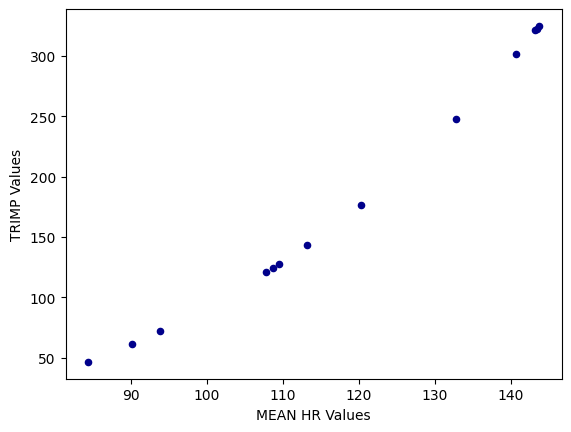

In [14]:
ax1=InternalLoads.plot.scatter(x='MEAN HR Values', y='TRIMP Values', c='DarkBlue')

### Step 9

In [15]:
# Identify the athletes with the top 5 TRIMP and player load scores.
# Which of these was not part of the top 5 on March 8th (answer can be found by looking back at the workbook which focused on March 8th)
Rank_Max_PL
InternalLoads['Player Load']=Rank_Max_PL['Player Load']
print(InternalLoads)

            TRIMP Values  MEAN HR Values  Player Load
AthleteID                                            
Athlete 1     321.041173      143.249696        919.4
Athlete 10    324.822671      143.739545       1038.8
Athlete 11    124.477146      108.726088        342.1
Athlete 12     61.631714       90.120524        355.9
Athlete 13    127.610514      109.495981        344.8
Athlete 2     176.621997      120.254834        549.3
Athlete 3      72.469069       93.868420        337.3
Athlete 4      46.512651       84.351072        422.6
Athlete 5     248.080302      132.837472        790.5
Athlete 6     120.657609      107.771711        265.9
Athlete 7     301.791750      140.687171        904.5
Athlete 8     143.089162      113.139310        470.6
Athlete 9     322.367890      143.422047        890.8


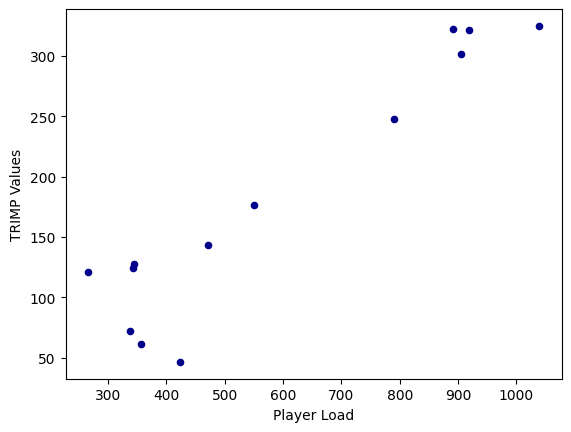

In [16]:
ax1=InternalLoads.plot.scatter(x='Player Load', y='TRIMP Values', c='DarkBlue')

By looking at the data we can see that the athletes with the top 5 TRIMP and player load scores are athletes 1, 10, 5, 7, and 9.  Going back to look at the game on March 8th, the player who was not part of that top 5 was athlete 7 who was dropped on the 8th because there was no heart rate value.  Therefore, our assumption from the previous notebook that the 5th woman (athlete 7) wasn't wearing the Catapult device seems to be correct.